---
**Title:** PPO — Proximal Policy Optimization

**Chapter:** Reinforcement Learning for LLMs

**Difficulty:** Intermediate

**Estimated Time:** 50 min

---

## Overview

### From REINFORCE to PPO

In the previous notebook we built **REINFORCE** — the simplest policy-gradient algorithm. It works, but it has two serious problems:

1. **High variance** — the training curve is noisy and unpredictable
2. **No safety net** — one bad gradient update can undo all progress

**PPO (Proximal Policy Optimization)** solves both problems by adding:
- A **value function** to reduce variance
- A **reference model** to prevent reward hacking
- A **clipping mechanism** to bound how much the policy changes per step

PPO is the algorithm behind ChatGPT and GPT-4's RLHF training. In this notebook, we'll build it step by step, component by component.

### What We'll Build

| Section | What | Why |
|---------|------|-----|
| REINFORCE recap | Quick refresher on the baseline | See the problems we're fixing |
| 4-model build-up | Add models one at a time | Understand *why* PPO needs 4 models |
| PPO clipping | The core mechanism | Bounded, stable updates |
| Full PPO training | End-to-end on TinyLM | See it work in practice |
| Hyperparameter sweep | Vary ε | Develop intuition for tuning |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from collections import Counter
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import (
    draw_training_pipeline, draw_rlhf_architecture,
    draw_ppo_clip, draw_progressive_models,
)
from mp_tutorial.formatting import (
    info_box, comparison_table, formula_breakdown,
)
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

torch.manual_seed(42)
print("Ready!")

Ready!


## TinyLM Setup

We reuse the same tiny language model from notebook 00. It has a 5-word vocabulary and generates 3-token sequences — small enough to see exactly what the model learns, but the concepts scale directly to GPT-scale models.

In [2]:
# ── Our tiny language model (same as notebook 00) ──
VOCAB = ["I", "love", "cats", "hate", "dogs"]
V = len(VOCAB)
SEQ_LEN = 3

def decode(token_ids):
    """Convert token indices to words."""
    return " ".join(VOCAB[t] for t in token_ids.tolist())


class TinyLM(nn.Module):
    """A minimal autoregressive language model.

    Given a sequence of tokens, predicts the next token at each position.
    This is exactly what GPT does — just with 5 words instead of 50,000.
    """
    def __init__(self, vocab_size=V, embed_dim=8, hidden_dim=16):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        """Forward pass (teacher-forced): returns logits at every position."""
        e = self.embed(x)
        h, _ = self.rnn(e)
        return self.head(h)  # (batch, seq_len, vocab_size)

    def log_probs_of(self, sequences):
        """Compute log P(sequence) under the current policy.

        Sums log-probabilities of tokens at positions 1, 2, ..., T-1
        (position 0 is the fixed start token).
        """
        logits = self.forward(sequences)           # (B, T, V)
        dist = torch.distributions.Categorical(logits=logits[:, :-1, :])
        per_token = dist.log_prob(sequences[:, 1:])  # (B, T-1)
        return per_token.sum(dim=1)                   # (B,)

    @torch.no_grad()
    def generate(self, batch_size, seq_len=SEQ_LEN):
        """Generate sequences autoregressively (always starts with 'I')."""
        tokens = [torch.zeros(batch_size, 1, dtype=torch.long)]
        for _ in range(seq_len - 1):
            inp = torch.cat(tokens, dim=1)
            logits = self.forward(inp)[:, -1, :]
            token = torch.distributions.Categorical(logits=logits).sample()
            tokens.append(token.unsqueeze(1))
        return torch.cat(tokens, dim=1)


def reward_fn(sequences):
    """Score sequences: +1 for 'I love cats', penalize 'hate'.

    This is our stand-in for human preferences.
    In real RLHF, a learned reward model replaces this function.
    """
    rewards = []
    for seq in sequences:
        words = [VOCAB[t] for t in seq.tolist()]
        r = 0.0
        if "love" in words and "cats" in words:
            r = 1.0
        elif "love" in words:
            r = 0.3
        if "hate" in words:
            r -= 0.5
        rewards.append(r)
    return torch.tensor(rewards)


# Quick test
model = TinyLM()
seqs = model.generate(8)
for seq in seqs:
    print(f"  {decode(seq):20s}  reward = {reward_fn(seq.unsqueeze(0)).item():+.1f}")

  I I I                 reward = +0.0
  I cats love           reward = +1.0
  I cats dogs           reward = +0.0
  I cats hate           reward = -0.5
  I love I              reward = +0.3
  I hate dogs           reward = -0.5
  I hate love           reward = -0.2
  I dogs I              reward = +0.0


## REINFORCE's Problems

Let's quickly train REINFORCE to remind ourselves what the problems are. Watch the training curve — it's noisy and unpredictable.

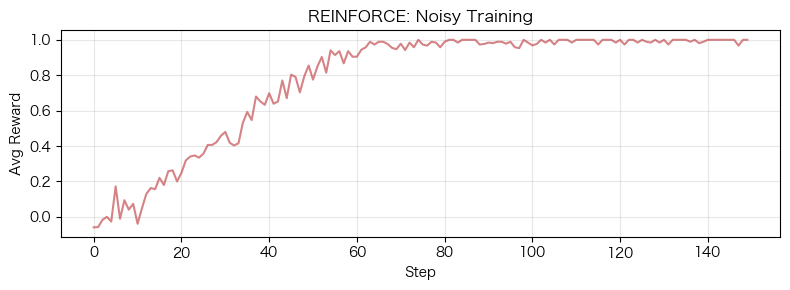

In [3]:
torch.manual_seed(42)
policy = TinyLM()
optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
reward_history = []
for step in range(150):
    seqs = policy.generate(batch_size=64)
    rewards = reward_fn(seqs)
    advantages = rewards - rewards.mean()
    log_probs = policy.log_probs_of(seqs)
    loss = -(log_probs * advantages).mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    reward_history.append(rewards.mean().item())

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(reward_history, color='#C44E52', lw=1.5, alpha=0.7)
ax.set_title("REINFORCE: Noisy Training", fontweight='bold')
ax.set_xlabel("Step"); ax.set_ylabel("Avg Reward"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

info_box("Two problems: <b>(1)</b> high variance — the curve is noisy and unpredictable. "
         "<b>(2)</b> no safety net — one bad update can undo all progress. PPO fixes both.", title="Why We Need PPO")

## Building Up: From 1 Model to 4

Real RLHF needs **4 models in memory simultaneously**. That sounds scary, so let's understand *why* by adding them one at a time — each solves a specific problem.

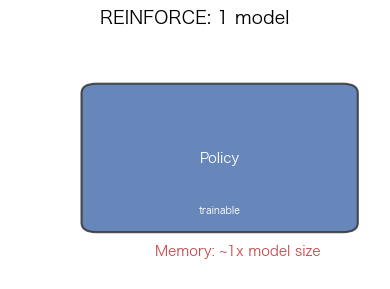

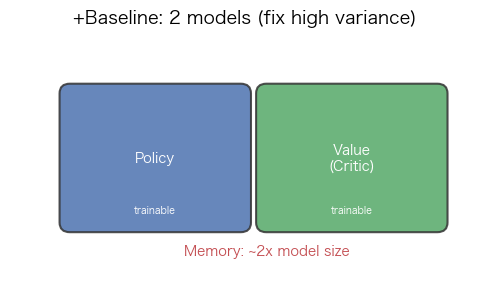

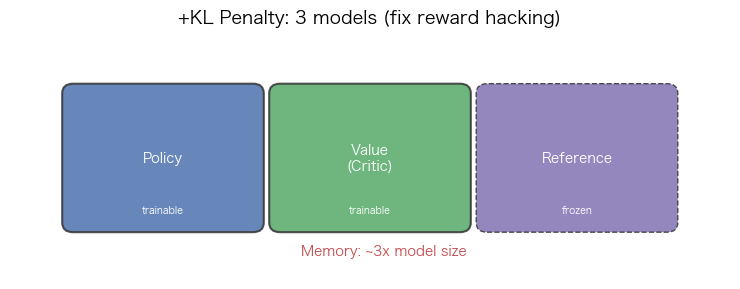

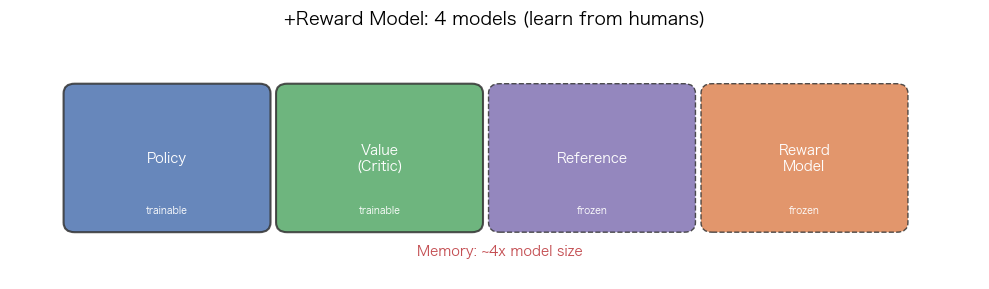

In [4]:
for stage in range(1, 5):
    fig, ax = draw_progressive_models(stage=stage)
    plt.show()

### Stage 1: Policy Only

This is just REINFORCE: one model generates sequences and updates itself based on rewards.

**Problem:** High variance and unstable training. The model has no frame of reference — it doesn't know if a reward of 0.3 is "good" or "bad" in context.

### Stage 2: Adding a Value Model

The **value function** $V(s)$ estimates "how good is this state on average?" It acts as a baseline, answering: "given where we are, what reward should we expect?"

**Advantage** is the difference between what we got and what we expected:

$$A = R - V(s)$$

- If $A > 0$: the outcome was *better* than expected — reinforce this behavior
- If $A < 0$: the outcome was *worse* than expected — discourage this behavior

This reduces variance because we're measuring *relative* performance instead of absolute rewards.

In [5]:
info_box("Think of it as grading on a curve. A score of 80% means nothing in isolation — "
         "but 80% when the class average is 60% means you did great. "
         "The value function <i>is</i> the class average.", title="Intuition: Grading on a Curve")

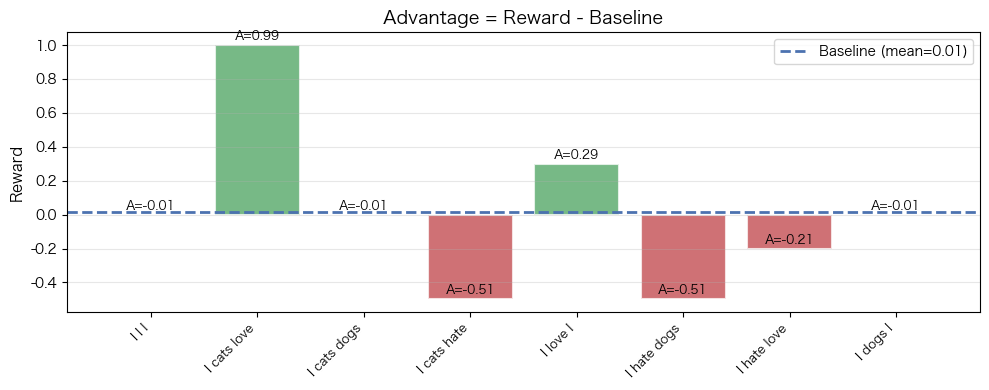

In [6]:
# Demonstrate advantage computation
torch.manual_seed(42)
policy = TinyLM()
seqs = policy.generate(8)
rewards = reward_fn(seqs)

# Simple baseline (mean reward) as a stand-in for learned value function
baseline = rewards.mean()
advantages = rewards - baseline

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(rewards))
labels = [decode(s) for s in seqs]

# Bar chart: rewards with baseline line
bars = ax.bar(x, rewards.numpy(), color=['#55A868' if a > 0 else '#C44E52' for a in advantages],
              edgecolor='white', linewidth=1.5, alpha=0.8)
ax.axhline(y=baseline.item(), color='#4C72B0', linestyle='--', lw=2, label=f'Baseline (mean={baseline:.2f})')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Reward", fontsize=11)
ax.set_title("Advantage = Reward - Baseline", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate advantages
for i, (bar, adv) in enumerate(zip(bars, advantages)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'A={adv:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

info_box("Green bars: positive advantage (better than average — reinforce). "
         "Red bars: negative advantage (worse than average — discourage). "
         "The baseline converts raw rewards into relative signals.", title="Advantage Visualization")

### Stage 3: Adding a Reference Model

Without constraints, the model can "hack" the reward — finding degenerate outputs that score high but are repetitive or nonsensical.

The **reference model** is a frozen copy of the initial policy. We use **KL divergence** to measure how far the current policy has drifted:

$$\text{KL}(\pi_\theta \| \pi_{\text{ref}}) = \mathbb{E}\left[ \log \frac{\pi_\theta(a|s)}{\pi_{\text{ref}}(a|s)} \right]$$

By adding $\beta \cdot \text{KL}$ as a penalty to the loss, we keep the model "close" to its original behavior — allowing improvement without collapse.

### Reward Hacking in Action

Let's see what happens when we train aggressively *without* a KL penalty. The model will find a "cheat code" — one sequence that maximizes reward — and collapse to generating it repeatedly.

In [7]:
# Train aggressively WITHOUT KL penalty
torch.manual_seed(42)
policy_no_kl = TinyLM()
ref_model = deepcopy(policy_no_kl)
for param in ref_model.parameters():
    param.requires_grad = False
optimizer = torch.optim.Adam(policy_no_kl.parameters(), lr=1e-2)  # aggressive LR

for step in range(200):
    seqs = policy_no_kl.generate(batch_size=128)
    rewards = reward_fn(seqs)
    advantages = rewards - rewards.mean()
    log_probs = policy_no_kl.log_probs_of(seqs)
    loss = -(log_probs * advantages).mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()

# Check KL divergence
with torch.no_grad():
    test_seqs = policy_no_kl.generate(200)
    new_lp = policy_no_kl.log_probs_of(test_seqs)
    ref_lp = ref_model.log_probs_of(test_seqs)
    kl = (new_lp - ref_lp).mean().item()

print(f"KL divergence from reference: {kl:.2f}")
print(f"\nGenerated sequences (no KL penalty):")
counts = Counter(decode(s) for s in test_seqs)
for text, count in counts.most_common(5):
    print(f"  {text:20s}  freq={count/200:.0%}")

info_box("Without a KL penalty, the model collapses to generating the same sequence over and over. "
         "It found the 'cheat code' — one sequence that maximizes reward. "
         "This is <b>reward hacking</b>, and it produces boring, repetitive output.", title="Reward Hacking")

KL divergence from reference: 2.97

Generated sequences (no KL penalty):
  I love cats           freq=70%
  I cats love           freq=29%
  I dogs love           freq=0%


### KL Divergence: The Drift Detector

**KL divergence** measures "how different is the new policy from the reference?"

| KL Value | Meaning |
|----------|---------|
| KL = 0 | Policies are identical — no learning happened |
| KL small (0.01 - 0.1) | Modest improvement — safe zone |
| KL large (> 1.0) | The model has changed dramatically — danger zone |

We add $\beta \cdot \text{KL}$ as a penalty to the loss. This creates a tug-of-war:
- The reward signal pulls the model toward high-reward outputs
- The KL penalty pulls it back toward the reference

The balance point is a model that's *better* than the reference but still *recognizably similar*.

### Stage 4: Adding a Reward Model

In real RLHF, rewards don't come from a hand-coded function like our `reward_fn`. Instead, they come from a **learned reward model** trained on human preference data:

> "Given response A and response B to the same prompt, which one does the human prefer?"

The reward model converts these pairwise preferences into a scalar score for any response. This is the 4th and final model.

**The full PPO/RLHF setup:**

| Model | Role | Trainable? |
|-------|------|------------|
| Policy (Actor) | Generates text | Yes |
| Value (Critic) | Estimates expected reward | Yes |
| Reference | Frozen copy of initial policy | No |
| Reward | Scores responses | No |

In [8]:
info_box("4 copies of a 7B model = <b>56 GB</b> in fp16, before optimizer states! "
         "With Adam optimizer (2 states per param), the policy alone needs 42 GB. "
         "Total: roughly <b>100+ GB</b> just for a 7B PPO setup. "
         "This is why model parallelism matters for RL.", title="Memory Reality Check")

## The PPO Clipping Trick

This is the heart of PPO — the mechanism that makes training stable.

### Probability Ratio

PPO computes a **probability ratio** between the new and old policy:

$$r(\theta) = \frac{\pi_{\text{new}}(a|s)}{\pi_{\text{old}}(a|s)}$$

What this ratio tells us:
- $r = 1$: the new policy behaves identically to the old one (no change)
- $r = 2$: the new policy is 2x more likely to take this action (big shift)
- $r = 0.5$: the new policy is half as likely (shifted away)

### The Clip

PPO **clips** this ratio to $[1-\varepsilon, \; 1+\varepsilon]$ (typically $\varepsilon = 0.2$):

$$L^{\text{CLIP}} = \min\left( r(\theta) \cdot A, \;\; \text{clip}(r(\theta),\; 1-\varepsilon,\; 1+\varepsilon) \cdot A \right)$$

The `min` is the key — it takes the *more conservative* option:
- For **good actions** (A > 0): the ratio can increase to 1.2 but no further
- For **bad actions** (A < 0): the ratio can decrease to 0.8 but no further

This prevents the model from over-committing to any single update.

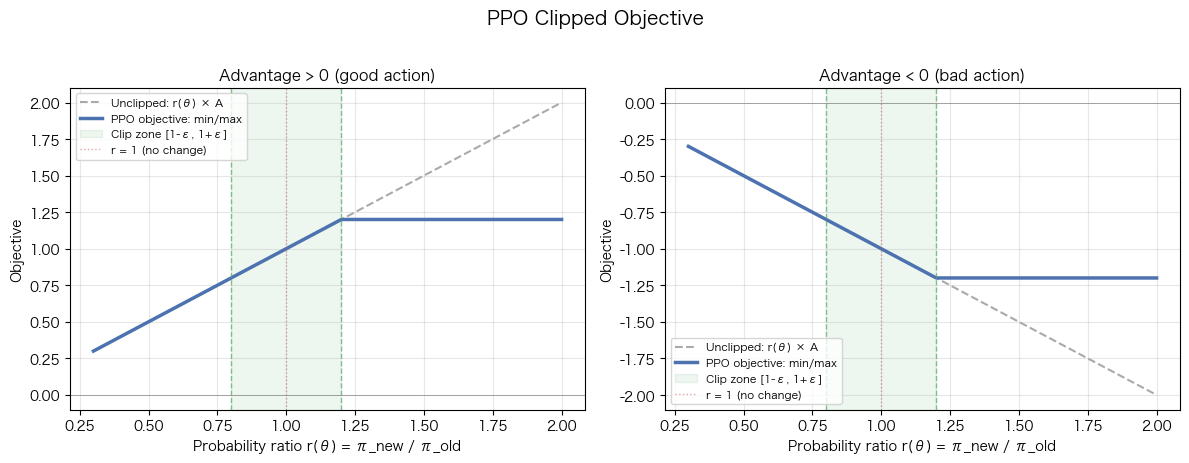

In [9]:
fig, axes = draw_ppo_clip(eps=0.2)
plt.show()

info_box("<b>Left:</b> Positive advantage (good action) — ratio can increase up to 1+\u03b5 but no further.<br>"
         "<b>Right:</b> Negative advantage (bad action) — ratio can decrease to 1-\u03b5 but no further.<br>"
         "This prevents both overcommitment to good actions and overreaction to bad ones.",
         title="Reading the PPO Clip Plot")

In [10]:
formula_breakdown([
    (
        "Probability ratio — how much did the<br>"
        "policy change for this action?",
        "r(\u03b8) = \u03c0<sub>new</sub>(a|s) / \u03c0<sub>old</sub>(a|s)",
        "ratio = (new_lp - old_lp).exp()",
    ),
    (
        "Clip the ratio — prevent drastic changes.<br>"
        "Keeps ratio in [1-\u03b5, 1+\u03b5]",
        "clip(r, 1-\u03b5, 1+\u03b5)",
        "clipped = torch.clamp(ratio, 1-eps, 1+eps)",
    ),
    (
        "Take the conservative option —<br>"
        "min of clipped and unclipped surrogate",
        "min(r\u00b7A, clip(r)\u00b7A)",
        "loss = -torch.min(ratio*adv, clipped*adv).mean()",
    ),
    (
        "KL penalty — don't drift too far from<br>"
        "the reference model",
        "\u03b2 \u00b7 KL(\u03c0<sub>\u03b8</sub> \u2016 \u03c0<sub>ref</sub>)",
        "kl_loss = kl_coeff * (new_lp - ref_lp).mean()",
    ),
], title="PPO Loss — Term by Term")

In Plain English,Math,PyTorch
Probability ratio — how much did thepolicy change for this action?,r(θ) = πnew(a|s) / πold(a|s),ratio = (new_lp - old_lp).exp()
"Clip the ratio — prevent drastic changes.Keeps ratio in [1-ε, 1+ε]","clip(r, 1-ε, 1+ε)","clipped = torch.clamp(ratio, 1-eps, 1+eps)"
Take the conservative option —min of clipped and unclipped surrogate,"min(r·A, clip(r)·A)","loss = -torch.min(ratio*adv, clipped*adv).mean()"
KL penalty — don't drift too far fromthe reference model,β · KL(πθ ‖ πref),kl_loss = kl_coeff * (new_lp - ref_lp).mean()


### Why Multiple Updates Per Batch?

One of PPO's biggest advantages over REINFORCE is **sample efficiency**.

| Algorithm | Data Usage | Efficiency |
|-----------|-----------|------------|
| REINFORCE | Generate batch, one update, throw away data | Wasteful |
| PPO | Generate batch, **3-8 updates** on same data | Efficient |

This works because the clipping mechanism keeps each update small. Even after several updates on the same batch, the policy hasn't changed drastically — so the data is still "fresh enough" to learn from.

In practice, PPO typically runs **4 inner epochs** per batch of generated data.

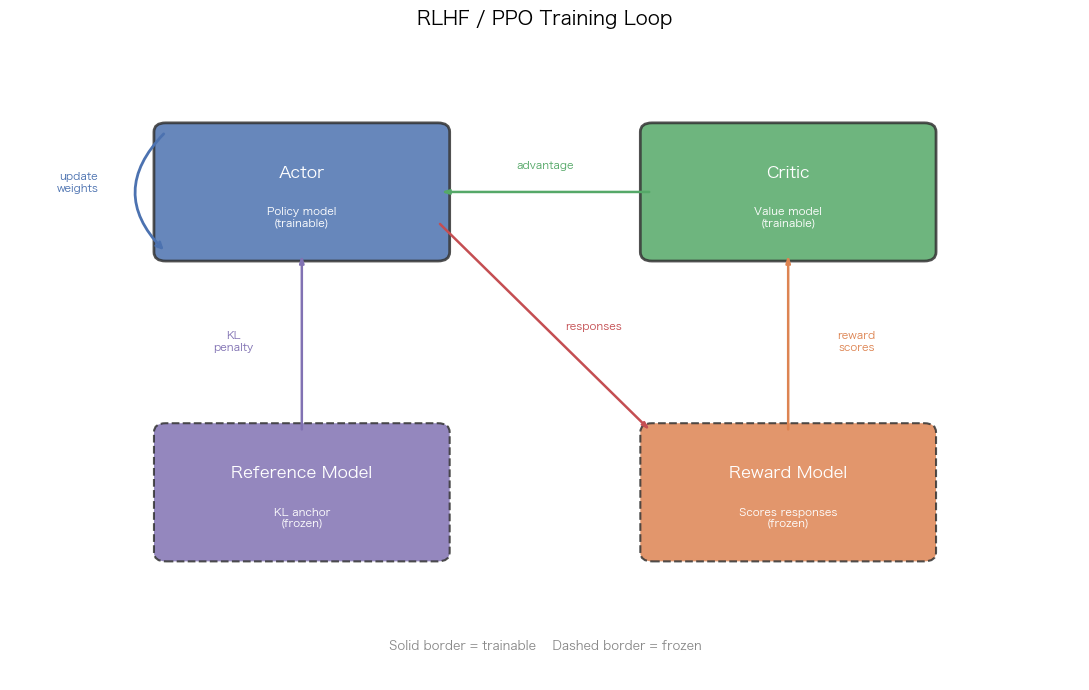

In [11]:
fig, ax = draw_rlhf_architecture()
plt.show()

## Full PPO Training

Now let's put it all together: clipping, KL penalty, multiple inner updates. We train our TinyLM with PPO for 80 epochs.

In [12]:
# ── Train with PPO ──
torch.manual_seed(42)
policy = TinyLM()
ref_model = deepcopy(policy)  # Frozen reference
for p in ref_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(policy.parameters(), lr=3e-3)
eps_clip = 0.2
kl_coeff = 0.15
reward_hist, kl_hist = [], []

for epoch in range(80):
    # 1. Collect data with current policy
    seqs = policy.generate(batch_size=128)
    rewards = reward_fn(seqs)
    with torch.no_grad():
        old_lp = policy.log_probs_of(seqs)
        ref_lp = ref_model.log_probs_of(seqs)

    advantages = rewards - rewards.mean()

    # 2. Multiple update steps on same batch (PPO's key feature)
    for _ in range(4):
        new_lp = policy.log_probs_of(seqs)
        ratio = (new_lp - old_lp).exp()

        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - eps_clip, 1 + eps_clip) * advantages
        ppo_loss = -torch.min(surr1, surr2).mean()

        kl = (new_lp - ref_lp).mean()
        loss = ppo_loss + kl_coeff * kl

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    reward_hist.append(rewards.mean().item())
    kl_hist.append(kl.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  reward={rewards.mean():.3f}  KL={kl.item():.3f}")

print(f"\nFinal: reward={reward_hist[-1]:.3f}  KL={kl_hist[-1]:.3f}")

Epoch   0  reward=-0.055  KL=-0.004


Epoch  20  reward=0.898  KL=2.429
Epoch  40  reward=1.000  KL=3.049
Epoch  60  reward=0.989  KL=2.902



Final: reward=1.000  KL=2.960


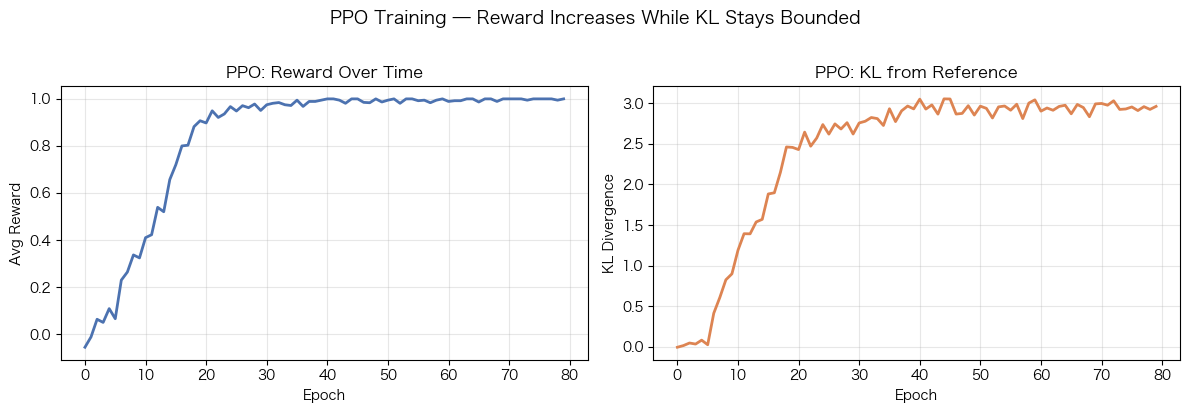

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(reward_hist, color="#4C72B0", lw=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Reward")
ax1.set_title("PPO: Reward Over Time", fontweight="bold")
ax1.grid(alpha=0.3)

ax2.plot(kl_hist, color="#DD8452", lw=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("KL Divergence")
ax2.set_title("PPO: KL from Reference", fontweight="bold")
ax2.grid(alpha=0.3)

plt.suptitle("PPO Training — Reward Increases While KL Stays Bounded",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

info_box(
    "Compare this to REINFORCE: the reward curve is <b>smoother</b> (less variance) "
    "and the KL divergence stays <b>bounded</b> (no reward hacking). "
    "This is PPO's promise — stable, controlled improvement.",
    title="PPO vs REINFORCE"
)

In [14]:
# What did PPO learn to generate?
print("Most common sequences after PPO training:\n")
seqs = policy.generate(500)
counts = Counter(decode(s) for s in seqs)
for text, count in counts.most_common(8):
    r = reward_fn(torch.tensor([[VOCAB.index(w) for w in text.split()]])).item()
    print(f"  {text:20s}  freq={count/500:.0%}  reward={r:+.1f}")

Most common sequences after PPO training:

  I love cats           freq=65%  reward=+1.0
  I cats love           freq=34%  reward=+1.0
  I cats I              freq=0%  reward=+0.0
  I love I              freq=0%  reward=+0.3
  I love love           freq=0%  reward=+0.3


## PPO vs REINFORCE: Side by Side

Let's put the two algorithms head to head. We retrain REINFORCE for a fair comparison and plot both training curves.

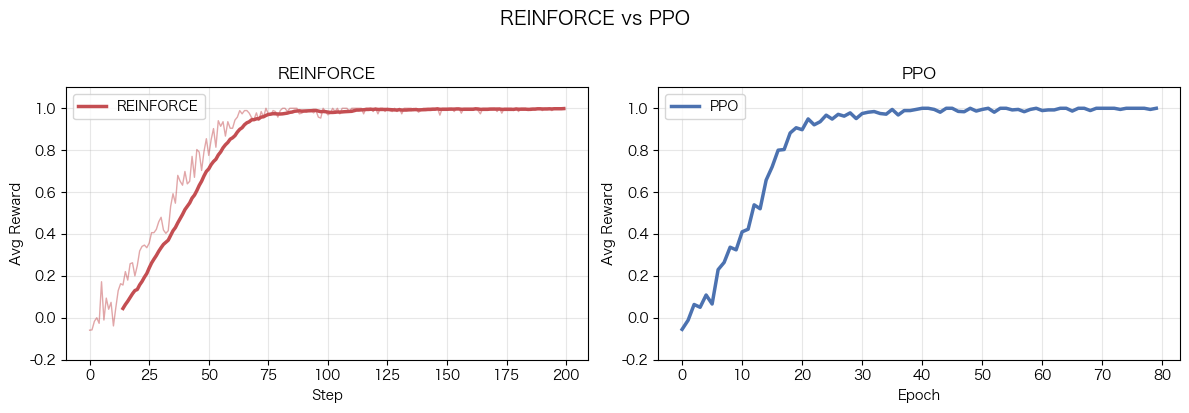

In [15]:
# Compare PPO vs REINFORCE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# REINFORCE curve (re-train quickly)
torch.manual_seed(42)
p_rf = TinyLM()
opt_rf = torch.optim.Adam(p_rf.parameters(), lr=5e-3)
rf_hist = []
for step in range(200):
    seqs = p_rf.generate(64)
    rewards = reward_fn(seqs)
    adv = rewards - rewards.mean()
    lp = p_rf.log_probs_of(seqs)
    loss = -(lp * adv).mean()
    opt_rf.zero_grad(); loss.backward(); opt_rf.step()
    rf_hist.append(rewards.mean().item())

ax1.plot(rf_hist, color='#C44E52', alpha=0.5, lw=1)
# smooth
w = 15
sm = np.convolve(rf_hist, np.ones(w)/w, mode='valid')
ax1.plot(range(w-1, len(rf_hist)), sm, color='#C44E52', lw=2.5, label='REINFORCE')
ax1.set_title("REINFORCE", fontweight='bold')
ax1.set_xlabel("Step"); ax1.set_ylabel("Avg Reward")
ax1.set_ylim(-0.2, 1.1); ax1.grid(alpha=0.3)
ax1.legend()

# PPO curve (already computed as reward_hist)
ax2.plot(reward_hist, color='#4C72B0', lw=2.5, label='PPO')
ax2.set_title("PPO", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Avg Reward")
ax2.set_ylim(-0.2, 1.1); ax2.grid(alpha=0.3)
ax2.legend()

plt.suptitle("REINFORCE vs PPO", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Hyperparameter Sensitivity

PPO has several key hyperparameters. Getting them right matters:

| Hyperparameter | Typical Value | Too Small | Too Large |
|---------------|---------------|-----------|-----------|
| **\u03b5** (clip range) | 0.1 - 0.3 | Slow learning (updates too conservative) | Unstable (defeats the purpose of clipping) |
| **\u03b2** (KL coefficient) | 0.01 - 0.2 | Reward hacking (model drifts freely) | No learning (model stuck near reference) |
| **Inner epochs** | 3 - 8 | Wasteful (throwing away data) | Stale data (updates based on outdated info) |
| **Batch size** | 128 - 512 | Noisy gradients | Slower per-step, but more stable |

Let's see the effect of clip range \u03b5 in practice:

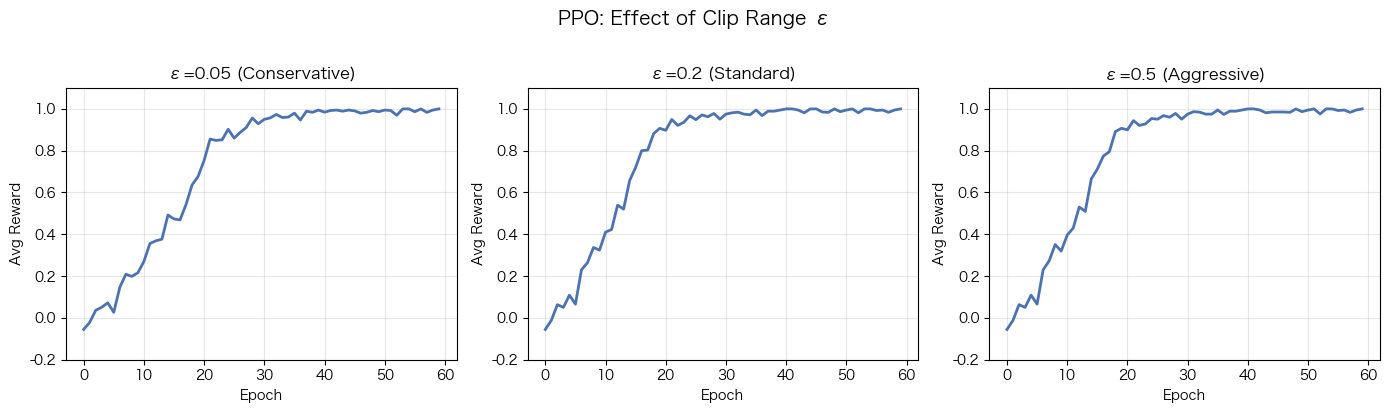

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, eps_val, title in zip(axes, [0.05, 0.2, 0.5],
                               ['\u03b5=0.05 (Conservative)', '\u03b5=0.2 (Standard)', '\u03b5=0.5 (Aggressive)']):
    torch.manual_seed(42)
    p = TinyLM()
    ref = deepcopy(p)
    for param in ref.parameters():
        param.requires_grad = False
    opt = torch.optim.Adam(p.parameters(), lr=3e-3)
    hist = []
    for epoch in range(60):
        seqs = p.generate(128)
        rewards = reward_fn(seqs)
        with torch.no_grad():
            old_lp = p.log_probs_of(seqs)
            ref_lp = ref.log_probs_of(seqs)
        advantages = rewards - rewards.mean()
        for _ in range(4):
            new_lp = p.log_probs_of(seqs)
            ratio = (new_lp - old_lp).exp()
            s1 = ratio * advantages
            s2 = torch.clamp(ratio, 1-eps_val, 1+eps_val) * advantages
            ppo_loss = -torch.min(s1, s2).mean()
            kl = (new_lp - ref_lp).mean()
            loss = ppo_loss + 0.15 * kl
            opt.zero_grad(); loss.backward(); opt.step()
        hist.append(rewards.mean().item())
    ax.plot(hist, color='#4C72B0', lw=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Reward")
    ax.set_ylim(-0.2, 1.1); ax.grid(alpha=0.3)

plt.suptitle("PPO: Effect of Clip Range \u03b5", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box("\u03b5=0.05 learns slowly (updates are too small). "
         "\u03b5=0.2 is the sweet spot — stable and effective. "
         "\u03b5=0.5 can be unstable — the clipping barely constrains updates.",
         title="Clip Range Takeaway")

## Summary

### What PPO Adds to REINFORCE

In [17]:
comparison_table(
    headers=["Component", "What It Does", "Problem It Solves"],
    rows=[
        ["Value Function (Critic)", "Estimates expected reward as baseline",
         "Reduces variance in gradient estimates"],
        ["Reference Model (frozen)", "Frozen copy of initial policy",
         "Prevents reward hacking via KL penalty"],
        ["Clipping (\u03b5)", "Bounds probability ratio to [1-\u03b5, 1+\u03b5]",
         "Prevents destructive large updates"],
        ["Multiple Inner Updates", "Reuses same batch for 3-8 gradient steps",
         "Better sample efficiency than REINFORCE"],
    ],
    title="PPO Components"
)

Component,What It Does,Problem It Solves
Value Function (Critic),Estimates expected reward as baseline,Reduces variance in gradient estimates
Reference Model (frozen),Frozen copy of initial policy,Prevents reward hacking via KL penalty
Clipping (ε),"Bounds probability ratio to [1-ε, 1+ε]",Prevents destructive large updates
Multiple Inner Updates,Reuses same batch for 3-8 gradient steps,Better sample efficiency than REINFORCE


### Key Takeaways

1. **PPO adds 3 components to REINFORCE:** value function, reference model, and clipping
2. **Clipping** prevents the policy from changing too much per step, giving stability
3. **KL penalty** prevents reward hacking — the model stays close to its reference
4. **Multiple updates per batch** make PPO much more sample-efficient
5. **4 models in memory:** policy (trainable), value (trainable), reference (frozen), reward (frozen)
6. **PPO is the "workhorse" of RLHF** — what ChatGPT and GPT-4 used for alignment

### The Cost

PPO works well, but it's expensive: 4 models in memory means ~56 GB for a 7B model in fp16, and 100+ GB once you add optimizer states. This motivates simpler alternatives.

In [18]:
info_box("PPO works well but requires <b>4 models</b> — that's 56 GB for a 7B model in fp16. "
         "Next notebook: <b>DPO (Direct Preference Optimization)</b> eliminates the reward model "
         "AND value function entirely, going from 4 models down to just 2.",
         title="Next: DPO — From 4 Models to 2")